In [1]:
import datetime
import requests
import base64
import zlib
import json

In [2]:
jsonData = requests.get(verify=False, url="https://d3ii0wo49og5mi.cloudfront.net/markets/mob:com?span=5y&ohlc=0&key=20240229:nazare").json()
jsonData

/opt/conda/lib/python3.7/site-packages/urllib3/connectionpool.py:1020: InsecureRequestWarning: Unverified HTTPS request is being made to host 'd3ii0wo49og5mi.cloudfront.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,


'a/lpZGluZ2VjbAM1MAYHSkOeRx8/jTUy90eLVCRjlAieZPxFWXTsPh4jvT0cG5Je7qcBjFatSUTkx+AoFbVc1gnrkkgipNgGycteuxbVm5GTG9fW1kDKh/Y3BzKJ3ZcW8tTeIsbIpL/SSsDC4BwvU46RHeAGkWNQ0xRcTM6EnuJtS02Tn5mXhNSchZXYl4afmuWSh7KLtKL0uDGg4pWBJDVc1Jypq2jzHFTN29KKm4ySVEu2g4qZQv+sWfK06KW0oLT8jVeQnoKbu1xxhGANmYraD5fOdJWuk8GYmoaJiLq90PMGk4SGhtAU95+AhYvVhhjtGxDe79jd9Be2eY2OTfS0s2bcj8kIEaydgN6qZNUF1fKbIEUN34Am3xOXRpyp2FvYeVekoomJ/oN02oDLIE0UfDkfx9r1bQkv63dLvZv8z/kXs0NFC1oDRGj5JlTlRaSHW5AAXVhg4wOW8ihBkvZd9ifRL4Kd4FWfTQjr2L16ddADhguwV94Xs5HfrAf7uoN6KKI4Gf8jJnYyushu5Na1mHXTE7oporNSVNvO74VrIk6kmlCTWpKiGI100xTXTxpkdfKImY0kJoQJELEKIIMCXtPqi8AxsM3zMHdbhSoId06h6qwCl8p5yU8kgI07mYF5/fg3kPRhOghlOLjmohmmxO10RAahFgDt/UV6JKLqVt7sMs03jV8hqG7rmiVuBU+ETKNJ02dDuDD2IClTy/ryw6UVA8VJP6LR6Zt31CMk0BDbE6URLw4gXM7W5Y4eMpjt0RMBohm0Hb5goq2vrxQR4SkaHRnzQA6ZjZOEnFFuphQ9ac/5k8Rx1Lw5in6mZT6cb6dCNayNIvx/oNoUy8j8EbFxRnzp7/X1jQmk5MtC0VeBHx+OBSmi3iW3fVO3jvuXDVSmcz4UZ95kHU8y0ZH5/SqZRgZa4AgLnzBKp+5rJ5IAh9kRNJ6tnIjC7NyxiUb+Fip0CcrJSMUwP7h2QglmHkTO4uIXoXvM7+6

In [15]:
jsonData = requests.get(verify=False, url="https://d3ii0wo49og5mi.cloudfront.net/markets/mob:com?interval=1d&span=5y&ohlc=0&key=20240229:nazare").json()

# Magic function from tradingeconomics
# function dataMagic(e, t) {
#     try {
#         let a = atob(e)
#           , n = new Uint8Array(a.length);
#         for (let e = 0; e < a.length; e++)
#             n[e] = a.charCodeAt(e);
#         const s = (new TextEncoder).encode(t);
#         for (let e = 0; e < n.length; e++)
#             n[e] ^= s[e % s.length];
#         const i = pako.inflate(n, {
#             to: "string"
#         });
#         return JSON.parse(i)
#     } catch (e) {
#         console.log(e)
#     }
# }

def data_magic(e, t, z):
    try:
        a = base64.b64decode(e)
        n = bytearray(a)
        s = bytearray(t, 'utf-8')
        for i in range(len(n)):
            n[i] ^= s[i % len(s)]
        i = zlib.decompress(n, z).decode('utf-8')
        return json.loads(i)
    except Exception as e:
        print(e)
        # pass


data = data_magic(jsonData, "tradingeconomics-charts-core-api-key", 16)

/opt/conda/lib/python3.7/site-packages/urllib3/connectionpool.py:1020: InsecureRequestWarning: Unverified HTTPS request is being made to host 'd3ii0wo49og5mi.cloudfront.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,


In [16]:
import pandas as pd
df = pd.DataFrame(data['series'][0]['data'])
df

,0,1,2,3
0,1615161600,592.019,NaN,NaN
1,1615248000,586.526,-0.928,-5.493
2,1615334400,589.307,0.474,2.781
3,1615420800,596.782,1.268,7.475
4,1615507200,597.151,0.062,0.369
...,...,...,...,...
1250,1772064000,570.782,0.074,0.423
1251,1772150400,588.277,3.065,17.495
1252,1772409600,633.492,7.686,45.215
1253,1772496000,669.880,5.744,36.388


In [17]:
df.rename(columns={0:'date', 1:'price', 2:'percentChange', 3:'change'}, inplace=True)

In [18]:
df["date"] = df["date"].apply(lambda x: datetime.datetime.fromtimestamp(x, datetime.timezone.utc))

In [19]:
df

,date,price,percentChange,change
0,2021-03-08 00:00:00+00:00,592.019,NaN,NaN
1,2021-03-09 00:00:00+00:00,586.526,-0.928,-5.493
2,2021-03-10 00:00:00+00:00,589.307,0.474,2.781
3,2021-03-11 00:00:00+00:00,596.782,1.268,7.475
4,2021-03-12 00:00:00+00:00,597.151,0.062,0.369
...,...,...,...,...
1250,2026-02-26 00:00:00+00:00,570.782,0.074,0.423
1251,2026-02-27 00:00:00+00:00,588.277,3.065,17.495
1252,2026-03-02 00:00:00+00:00,633.492,7.686,45.215
1253,2026-03-03 00:00:00+00:00,669.880,5.744,36.388


In [20]:
df.to_csv(f'Naphtha.csv',index=None)

In [33]:
url = ["https://d3ii0wo49og5mi.cloudfront.net/markets/s%201:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/w%201:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/da:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/kc1:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/ct1:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/rr1:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/sb1:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/tea:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/sunf:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/fapp:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare",
      "https://d3ii0wo49og5mi.cloudfront.net/markets/c%201:com?interval=1d&span=1y&ohlc=0&key=20240229:nazare"]

In [34]:
crops = ["Soybeans","Wheat","Milk","Coffee","Cotton","Rice","Sugar","Tea","Sunflower Oil","Potatoes","Corn"]

In [35]:
def create_df(url,crop):
    jsonData = requests.get(verify=False, url=url).json()
    data = data_magic(jsonData, "tradingeconomics-charts-core-api-key", 16)
    df = pd.DataFrame(data['series'][0]['data'])
    df.rename(columns={0:'date', 1:'price', 2:'percentChange', 3:'change'}, inplace=True)
    df["date"] = df["date"].apply(lambda x: datetime.datetime.fromtimestamp(x, datetime.timezone.utc))
    df.to_csv(f'{crop}.csv',index=None)

In [36]:
for url, crop in zip(url, crops):
    create_df(url, crop)

/opt/conda/lib/python3.7/site-packages/urllib3/connectionpool.py:1020: InsecureRequestWarning: Unverified HTTPS request is being made to host 'd3ii0wo49og5mi.cloudfront.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,
/opt/conda/lib/python3.7/site-packages/urllib3/connectionpool.py:1020: InsecureRequestWarning: Unverified HTTPS request is being made to host 'd3ii0wo49og5mi.cloudfront.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,
/opt/conda/lib/python3.7/site-packages/urllib3/connectionpool.py:1020: InsecureRequestWarning: Unverified HTTPS request is being made to host 'd3ii0wo49og5mi.cloudfront.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,
/

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# load all csv files in the folder
files = glob.glob("*.csv")

dataframes = {}

for file in files:
    name = file.replace(".csv", "")
    df = pd.read_csv(file, parse_dates=["date"])
    dataframes[name] = df

print("Loaded:", list(dataframes.keys()))


Loaded: ['Rice', 'cotton_INR', 'Cotton', 'Corn_INR', 'Tea', 'Sugar_INR', 'Coffee', 'cotton', 'Soybeans', 'Milk', 'Milk_INR', 'Wheat_INR', 'Tea_INR', 'Sunflower Oil_INR', 'Sunflower Oil', 'Potatoes_INR', 'Wheat', 'Sugar', 'Potatoes', 'Corn', 'Rice_INR', 'Soybeans_INR', 'Coffee_INR', 'Cotton_INR']


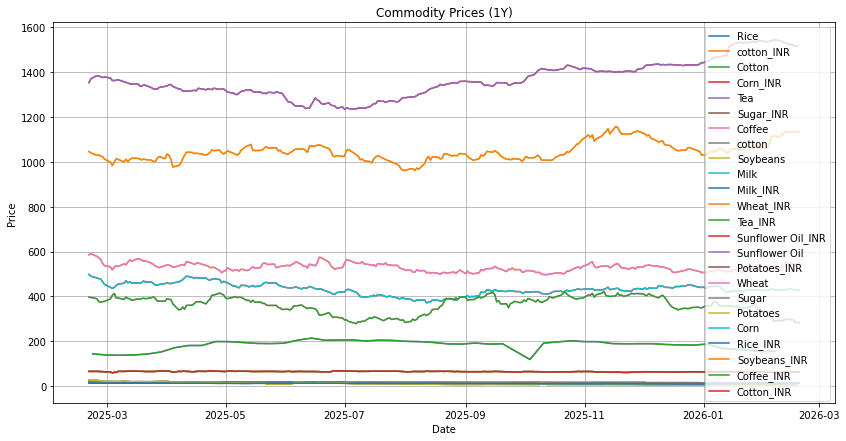

In [38]:
plt.figure(figsize=(14, 7))

for name, df in dataframes.items():
    plt.plot(df["date"], df["price"], label=name)

plt.title("Commodity Prices (1Y)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
commodity_currency = {
    "Soybeans": "USD",
    "Wheat": "USD",
    "Milk": "USD",
    "Coffee": "USD",
    "Cotton": "USD",
    "Rice": "USD",
    "Sugar": "USD",
    "Corn": "USD",
    "Potatoes": "EUR",
    "Sunflower_Oil": "INR",
    "Tea": "INR"
}


In [40]:
import requests

def get_fx_rates(base="INR"):
    url = f"https://open.er-api.com/v6/latest/{base}"
    data = requests.get(url).json()
    return data["rates"]

fx = get_fx_rates("INR")


In [41]:
fx_to_inr = {
    "USD": 1 / fx["USD"],
    "EUR": 1 / fx["EUR"],
    "CAD": 1 / fx["CAD"],
    "AUD": 1 / fx["AUD"],
    "MYR": 1 / fx["MYR"],
    "INR": 1
}

print(fx_to_inr)


{'USD': 90.77705156136528, 'EUR': 107.22710701265281, 'CAD': 66.36580833554552, 'AUD': 64.06149903907752, 'MYR': 23.264470500651406, 'INR': 1}


In [42]:
import glob
import pandas as pd

for file in glob.glob("*.csv"):
    commodity = file.replace(".csv", "")
    
    df = pd.read_csv(file, parse_dates=["date"])
    
    currency = commodity_currency.get(commodity, "USD")
    df["price_inr"] = df["price"] * fx_to_inr[currency]
    
    df.to_csv(f"{commodity}_INR.csv", index=False)


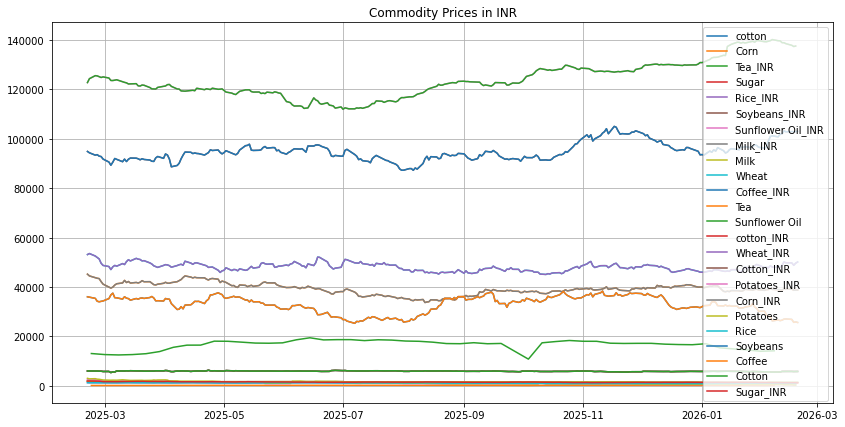

In [43]:
import matplotlib.pyplot as plt
import glob

plt.figure(figsize=(14, 7))

for file in glob.glob("*_INR.csv"):
    name = file.replace("_INR.csv", "")
    df = pd.read_csv(file, parse_dates=["date"])
    plt.plot(df["date"], df["price_inr"], label=name)

plt.title("Commodity Prices in INR")
plt.legend()
plt.grid(True)
plt.show()


In [44]:
import pandas as pd
import glob

dfs = []

for file in glob.glob("*_INR.csv"):
    name = file.replace("_INR.csv", "")
    df = pd.read_csv(file, parse_dates=["date"])
    df = df[["date", "price_inr"]]
    df.rename(columns={"price_inr": name}, inplace=True)
    dfs.append(df)

from functools import reduce
prices = reduce(lambda left, right: pd.merge(left, right, on="date", how="outer"), dfs)

prices = prices.sort_values("date").set_index("date")


In [45]:
prices

,cotton,Corn,Tea_INR,Sugar,Rice_INR,Soybeans_INR,Sunflower Oil_INR,Milk_INR,Milk,Wheat,...,Wheat_INR,Cotton_INR,Potatoes_INR,Corn_INR,Potatoes,Rice,Soybeans,Coffee,Cotton,Sugar_INR
date,,,,,,,,,,,,,,,,,,,,,
2025-02-20 00:00:00+00:00,5997.322077,45208.941540,NaN,1914.624183,1266.793755,94907.407407,122794.117647,1844.589688,1844.589688,53149.963689,...,53149.963689,5997.322077,2559.912854,45208.941540,3023.804418,1266.793755,94907.407407,36049.673203,5997.322077,1914.624183
2025-02-21 00:00:00+00:00,5997.049746,44504.084967,NaN,1933.732752,1234.567901,94362.745098,124373.638344,1835.511983,1835.511983,53561.056645,...,53561.056645,5997.049746,2387.436456,44504.084967,2820.072914,1234.567901,94362.745098,35887.999274,5997.049746,1933.732752
2025-02-22 00:00:00+00:00,NaN,NaN,13067.356572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-02-24 00:00:00+00:00,6023.583878,43799.927378,NaN,1910.984023,1220.497458,93409.586057,125599.128540,1835.511983,1835.511983,52559.912854,...,52559.912854,6023.583878,2441.902687,43799.927378,2884.409179,1220.497458,93409.586057,35414.469862,6023.583878,1910.984023
2025-02-25 00:00:00+00:00,5982.688816,43550.290487,NaN,1941.693900,1221.405229,93613.834423,125508.351489,1833.696442,1833.696442,51992.556282,...,51992.556282,5982.688816,2278.503994,43550.290487,2691.400386,1221.405229,93613.834423,34242.392883,5982.688816,1941.693900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13 00:00:00+00:00,5821.532317,39192.992012,NaN,1224.582426,1000.363108,102850.399419,138553.013798,1367.102397,1367.102397,49813.907044,...,49813.907044,5821.532317,363.108206,39192.992012,428.908428,1000.363108,102850.399419,27078.794481,5821.532317,1224.582426
2026-02-16 00:00:00+00:00,5825.862382,39126.125635,NaN,1229.929194,NaN,102916.820988,137890.341322,NaN,NaN,49788.444081,...,49788.444081,5825.862382,363.108206,39126.125635,428.908428,NaN,102916.820988,26890.259622,5825.862382,1229.929194
2026-02-17 00:00:00+00:00,5777.051561,38693.718228,NaN,1223.674655,976.307190,102941.176471,137400.145243,1367.102397,1367.102397,48815.359477,...,48815.359477,5777.051561,281.408860,38693.718228,332.404032,976.307190,102941.176471,25698.983297,5777.051561,1223.674655


In [46]:
weekly_prices = prices.resample("W").last()
returns = weekly_prices.pct_change().dropna()


In [47]:
weekly_prices

,cotton,Corn,Tea_INR,Sugar,Rice_INR,Soybeans_INR,Sunflower Oil_INR,Milk_INR,Milk,Wheat,...,Wheat_INR,Cotton_INR,Potatoes_INR,Corn_INR,Potatoes,Rice,Soybeans,Coffee,Cotton,Sugar_INR
date,,,,,,,,,,,,,,,,,,,,,
2025-02-23 00:00:00+00:00,5997.049746,44504.084967,13067.356572,1933.732752,1234.567901,94362.745098,124373.638344,1835.511983,1835.511983,53561.056645,...,53561.056645,5997.049746,2387.436456,44504.084967,2820.072914,1234.567901,94362.745098,35887.999274,5997.049746,1933.732752
2025-03-02 00:00:00+00:00,5794.380901,41167.392883,12639.796659,1679.248366,1205.973130,91820.987654,125099.854757,1836.419753,1836.419753,48747.276688,...,48747.276688,5794.380901,1997.095134,41167.392883,2358.996354,1205.973130,91820.987654,34361.619463,5794.380901,1679.248366
2025-03-09 00:00:00+00:00,6002.605301,41326.252723,12493.645606,1663.970588,1202.342048,91707.516340,123928.830792,1662.127814,1662.127814,48452.251271,...,48452.251271,6002.605301,1915.395788,41326.252723,2262.491958,1202.342048,91707.516340,35630.355846,6002.605301,1663.970588
2025-03-16 00:00:00+00:00,6109.622367,41621.278141,12644.335512,1742.892157,1239.560639,92229.484386,122240.377633,1683.006536,1683.006536,50562.817720,...,50562.817720,6109.622367,1851.851852,41621.278141,2187.432983,1239.560639,92229.484386,34685.911402,6109.622367,1742.892157
2025-03-23 00:00:00+00:00,5931.781046,42143.246187,13001.997095,1787.191358,1218.228032,91662.127814,121713.870733,1682.098765,1682.098765,50676.289034,...,50676.289034,5931.781046,1833.696442,42143.246187,2165.987562,1218.228032,91662.127814,35384.241104,5931.781046,1787.191358
2025-03-30 00:00:00+00:00,6072.431009,41144.698620,13869.825708,1730.519245,1226.851852,92864.923747,120851.488744,1692.992012,1692.992012,47952.977487,...,47952.977487,6072.431009,1997.095134,41144.698620,2358.996354,1226.851852,92864.923747,34459.213871,6072.431009,1730.519245
2025-04-06 00:00:00+00:00,5748.828976,41780.137981,15584.604212,1717.156863,1186.909949,88689.179375,121269.063181,1541.394336,1541.394336,48021.060276,...,48021.060276,5748.828976,1670.297749,41780.137981,1972.978769,1186.909949,88689.179375,33281.744735,5748.828976,1717.156863
2025-04-13 00:00:00+00:00,5977.124183,44503.449528,16461.510530,1632.598039,1225.944081,94657.770516,119317.356572,1560.457516,1560.457516,50449.346405,...,50449.346405,5977.124183,1588.598402,44503.449528,1876.474373,1225.944081,94657.770516,32681.054829,5977.124183,1632.598039
2025-04-20 00:00:00+00:00,6023.356935,43777.233115,16475.127088,1625.998548,1224.192084,94031.635802,120497.458243,1576.797386,1576.797386,49813.907044,...,49813.907044,6023.356935,1588.598402,43777.233115,1876.474373,1224.192084,94031.635802,34203.912491,6023.356935,1625.998548


In [48]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print("Stationary:", result[1] < 0.05)
    print("-" * 30)

for col in returns.columns:
    adf_test(returns[col], col)


cotton
ADF statistic: -2.3343530318881824
p-value: 0.16112763195647595
Stationary: False
------------------------------
Corn
ADF statistic: -9.606016253734047
p-value: 1.865354363085977e-16
Stationary: True
------------------------------
Tea_INR
ADF statistic: -9.874639896652393
p-value: 3.9118360914439637e-17
Stationary: True
------------------------------
Sugar
ADF statistic: -5.078637156528505
p-value: 1.5473966684053103e-05
Stationary: True
------------------------------
Rice_INR
ADF statistic: -7.133779498797193
p-value: 3.4631511414453643e-10
Stationary: True
------------------------------
Soybeans_INR
ADF statistic: -8.81060377565488
p-value: 1.996155090945809e-14
Stationary: True
------------------------------
Sunflower Oil_INR
ADF statistic: -5.519966714352074
p-value: 1.8873367698234433e-06
Stationary: True
------------------------------
Milk_INR
ADF statistic: -3.7526386595923547
p-value: 0.0034308023071220944
Stationary: True
------------------------------
Milk
ADF statisti

In [77]:
from statsmodels.tsa.arima.model import ARIMA

arima_forecasts = {}

for col in returns.columns:
    series = returns[col].dropna()

    model = ARIMA(series, order=(1, 0, 1))
    fitted = model.fit()

    forecast = fitted.forecast(steps=1)
    arima_forecasts[col] = forecast.iloc[0]

print("ARIMA next-week return forecasts:")
print(arima_forecasts)


ARIMA next-week return forecasts:
{'cotton': -0.007723979070414879, 'Corn': 0.0005771900243885645, 'Tea_INR': 0.01090696903988027, 'Sugar': -0.015341255104685862, 'Rice_INR': -0.004189450200563254, 'Soybeans_INR': -0.0035981201660337117, 'Sunflower Oil_INR': -0.0007090874390958536, 'Milk_INR': -0.012963085744048987, 'Milk': -0.012963085744048987, 'Wheat': -0.013847958509864193, 'Coffee_INR': -0.008824912629683788, 'Tea': 0.010906969121103758, 'Sunflower Oil': -0.0007090874390958536, 'cotton_INR': -0.008016758877827178, 'Wheat_INR': -0.013737970918911976, 'Cotton_INR': -0.007723979070414879, 'Potatoes_INR': 0.11665224443556012, 'Corn_INR': 0.0005832025224129689, 'Potatoes': 0.11665224465086223, 'Rice': -0.004189450200563254, 'Soybeans': -0.0035981201660337117, 'Coffee': -0.008824912629683788, 'Cotton': -0.007723979070414879, 'Sugar_INR': -0.015341255104685862}


In [50]:
!pip install arch

     |████████████████████████████████| 903 kB 5.1 MB/s            


In [78]:
from arch import arch_model

garch_forecasts = {}

for col in returns.columns:
    series = returns[col].dropna() * 100

    model = arch_model(series, vol="Garch", p=1, q=1)
    fitted = model.fit(disp="off")

    forecast = fitted.forecast(horizon=1)
    mean_forecast = forecast.mean.iloc[-1, 0] / 100

    garch_forecasts[col] = mean_forecast

print("GARCH next-week return forecasts:")
print(garch_forecasts)


GARCH next-week return forecasts:
{'cotton': 0.00012636968987103303, 'Corn': -0.0013348410492110207, 'Tea_INR': -0.009966357984853447, 'Sugar': -0.0069665384833233965, 'Rice_INR': -0.004909410402699015, 'Soybeans_INR': 0.0019542100896730906, 'Sunflower Oil_INR': 0.0019913081742777474, 'Milk_INR': -0.004830857022221613, 'Milk': -0.004830857022221613, 'Wheat': 0.00026028397586126066, 'Coffee_INR': -0.0072466745639738804, 'Tea': -0.00996637212088707, 'Sunflower Oil': 0.0019913081742777474, 'cotton_INR': 0.0001269511265385872, 'Wheat_INR': 0.00025417651966336605, 'Cotton_INR': 0.00012636968987103303, 'Potatoes_INR': -0.020887966123857366, 'Corn_INR': -0.0013356926750162817, 'Potatoes': -0.020888565361747786, 'Rice': -0.004909410402699015, 'Soybeans': 0.0019542100896730906, 'Coffee': -0.0072466745639738804, 'Cotton': 0.00012636968987103303, 'Sugar_INR': -0.0069665384833233965}


In [79]:
train_size = int(len(returns) * 0.8)

train = returns.iloc[:train_size]
test = returns.iloc[train_size:]


In [80]:
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

warnings.filterwarnings("ignore")

p_values = [0, 1, 2]
d_values = [0,1]
q_values = [0, 1, 2]


In [ ]:
results = {}

for col in returns.columns:
    print(f"\nCommodity: {col}")
    
    series_train = train[col].dropna()
    series_test = test[col].dropna()
    
    best_score = float("inf")
    best_cfg = None
    
    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    model = ARIMA(series_train, order=(p, d, q))
                    fitted = model.fit()
                    
                    preds = fitted.forecast(steps=len(series_test))
                    
                    rmse = np.sqrt(mean_squared_error(series_test, preds))
                    mae = mean_absolute_error(series_test, preds)
                    
                    print(f"ARIMA({p},{d},{q}) RMSE={rmse:.5f} MAE={mae:.5f}")
                    
                    if rmse < best_score:
                        best_score = rmse
                        best_cfg = (p, d, q)
                
                except:
                    continue
    
    results[col] = best_cfg
    print("Best model:", best_cfg)



Commodity: cotton
ARIMA(0,0,0) RMSE=0.01944 MAE=0.01254
ARIMA(0,0,1) RMSE=0.01970 MAE=0.01335
ARIMA(0,0,2) RMSE=0.01956 MAE=0.01307
ARIMA(0,1,0) RMSE=0.02510 MAE=0.02209
ARIMA(0,1,1) RMSE=0.01944 MAE=0.01254
ARIMA(0,1,2) RMSE=0.02119 MAE=0.01496
ARIMA(1,0,0) RMSE=0.01962 MAE=0.01339
ARIMA(1,0,1) RMSE=0.01955 MAE=0.01301
ARIMA(1,0,2) RMSE=0.01958 MAE=0.01312
ARIMA(1,1,0) RMSE=0.02761 MAE=0.02519
ARIMA(1,1,1) RMSE=0.01961 MAE=0.01337
ARIMA(1,1,2) RMSE=0.02088 MAE=0.01489
ARIMA(2,0,0) RMSE=0.01980 MAE=0.01366
ARIMA(2,0,1) RMSE=0.01956 MAE=0.01303
ARIMA(2,0,2) RMSE=0.01949 MAE=0.01267
ARIMA(2,1,0) RMSE=0.02329 MAE=0.01924
ARIMA(2,1,1) RMSE=0.01975 MAE=0.01361
ARIMA(2,1,2) RMSE=0.02060 MAE=0.01451
Best model: (0, 1, 1)

Commodity: Corn
ARIMA(0,0,0) RMSE=0.01910 MAE=0.01538
ARIMA(0,0,1) RMSE=0.01920 MAE=0.01547
ARIMA(0,0,2) RMSE=0.01899 MAE=0.01510
ARIMA(0,1,0) RMSE=0.01968 MAE=0.01395
ARIMA(0,1,1) RMSE=0.01909 MAE=0.01524
ARIMA(0,1,2) RMSE=0.01946 MAE=0.01436
ARIMA(1,0,0) RMSE=0.01915 MAE=

In [82]:
print("Best ARIMA configuration per commodity:")
print(results)

Best ARIMA configuration per commodity:
{'cotton': (0, 1, 1), 'Corn': (2, 0, 2), 'Tea_INR': (0, 1, 0), 'Sugar': (1, 1, 0), 'Rice_INR': (2, 0, 2), 'Soybeans_INR': (1, 1, 2), 'Sunflower Oil_INR': (0, 1, 1), 'Milk_INR': (1, 1, 2), 'Milk': (1, 1, 2), 'Wheat': (1, 0, 1), 'Coffee_INR': (0, 1, 0), 'Tea': (0, 1, 0), 'Sunflower Oil': (0, 1, 1), 'cotton_INR': (0, 1, 1), 'Wheat_INR': (1, 0, 1), 'Cotton_INR': (0, 1, 1), 'Potatoes_INR': (2, 1, 0), 'Corn_INR': (2, 0, 2), 'Potatoes': (2, 1, 0), 'Rice': (2, 0, 2), 'Soybeans': (1, 1, 2), 'Coffee': (0, 1, 0), 'Cotton': (0, 1, 1), 'Sugar_INR': (1, 1, 0)}


In [83]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rolling_arima_forecast(series, order, train_size):
    history = list(series[:train_size])
    test = series[train_size:]
    
    predictions = []
    
    for t in range(len(test)):
        model = ARIMA(history, order=order)
        fitted = model.fit()
        
        forecast = fitted.forecast()[0]
        predictions.append(forecast)
        
        history.append(test.iloc[t])
    
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)
    
    return rmse, mae, predictions



Rolling ARIMA → cotton
RMSE: 0.019632592022003237
MAE: 0.012649241710262561


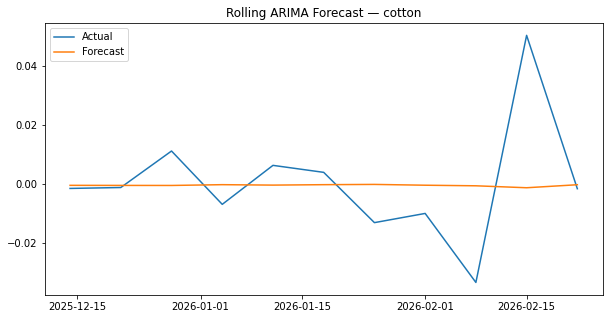


Rolling ARIMA → Corn
RMSE: 0.016737553095110356
MAE: 0.013290495036932857


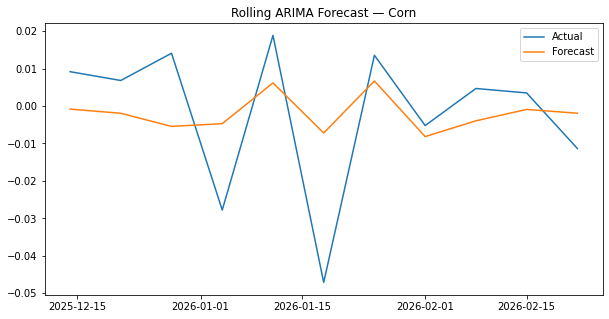


Rolling ARIMA → Tea_INR
RMSE: 0.04689022092605469
MAE: 0.030416292577191504


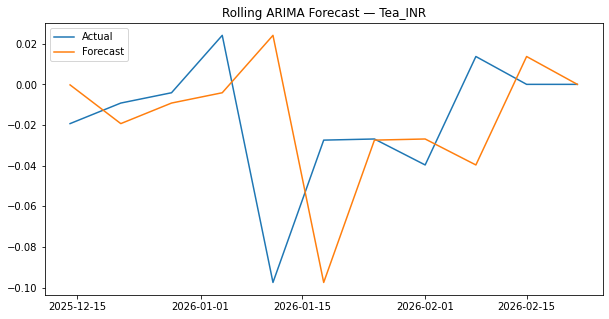


Rolling ARIMA → Sugar
RMSE: 0.026415391441055612
MAE: 0.024852803752037942


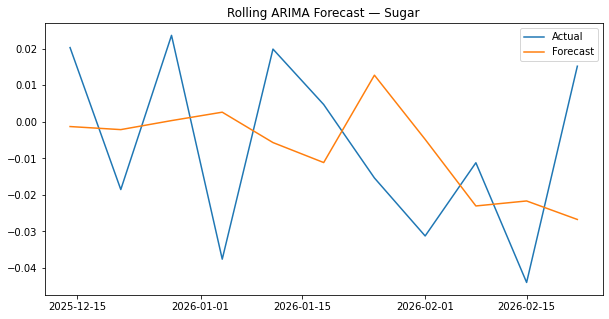


Rolling ARIMA → Rice_INR
RMSE: 0.043673054845220306
MAE: 0.03447031102812791


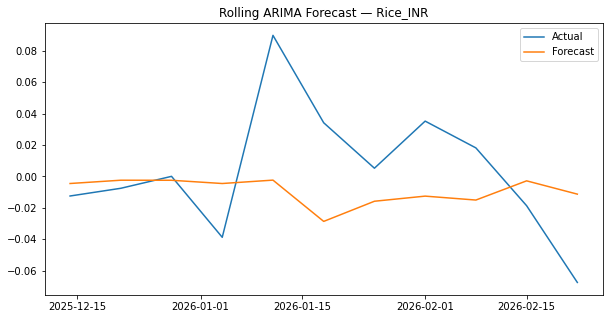


Rolling ARIMA → Soybeans_INR
RMSE: 0.022306610270125246
MAE: 0.017744439377035893


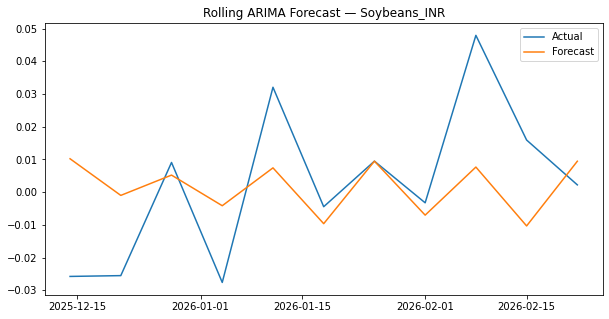


Rolling ARIMA → Sunflower Oil_INR
RMSE: 0.013462224297290907
MAE: 0.010123202091968053


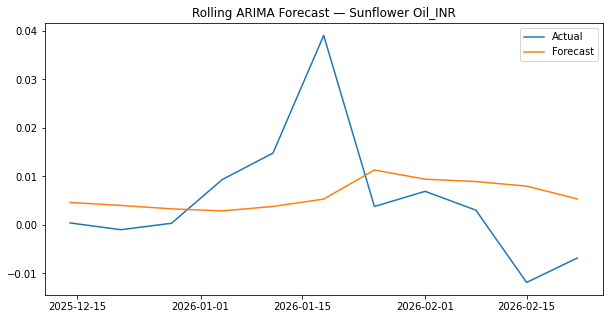


Rolling ARIMA → Milk_INR
RMSE: 0.022310868390756633
MAE: 0.01344711201743378


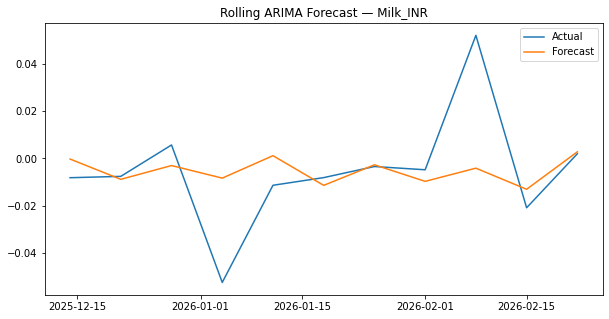


Rolling ARIMA → Milk
RMSE: 0.022310868390756633
MAE: 0.01344711201743378


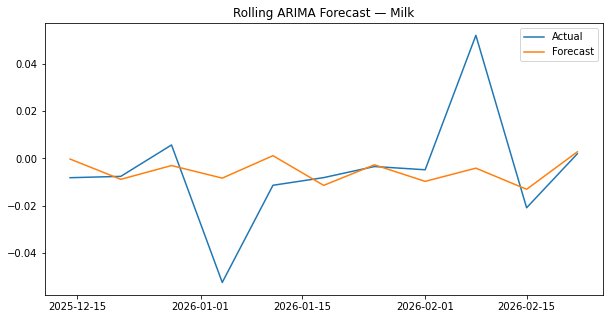


Rolling ARIMA → Wheat
RMSE: 0.027326542472262322
MAE: 0.023161274657945752


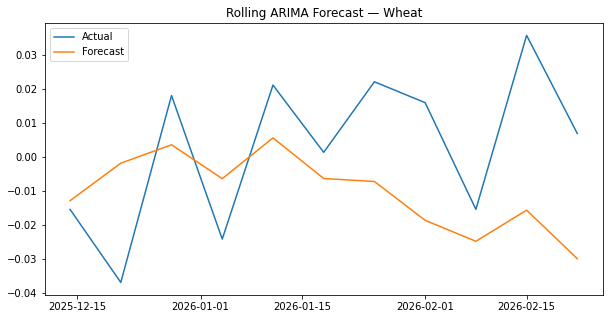


Rolling ARIMA → Coffee_INR
RMSE: 0.0875423896607914
MAE: 0.06349087210927863


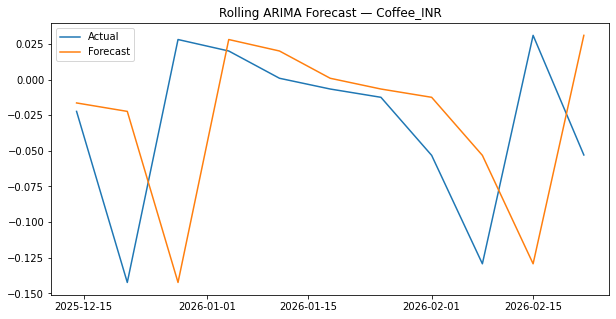


Rolling ARIMA → Tea
RMSE: 0.04689022092605474
MAE: 0.030416292577191542


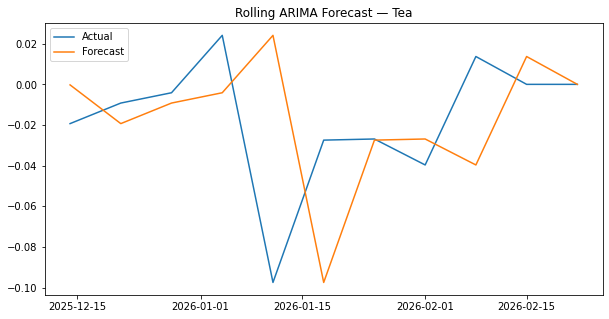


Rolling ARIMA → Sunflower Oil
RMSE: 0.013462224297290907
MAE: 0.010123202091968053


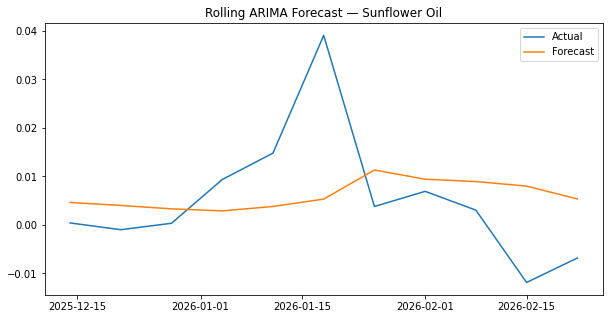


Rolling ARIMA → cotton_INR
RMSE: 0.01963004930979985
MAE: 0.012603737549679661


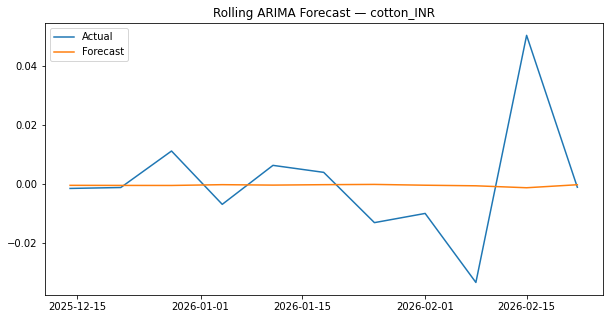


Rolling ARIMA → Wheat_INR
RMSE: 0.02727548988664913
MAE: 0.023123204664158237


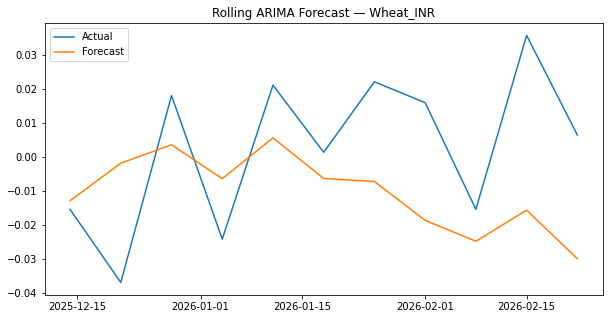


Rolling ARIMA → Cotton_INR
RMSE: 0.019632592022003237
MAE: 0.012649241710262561


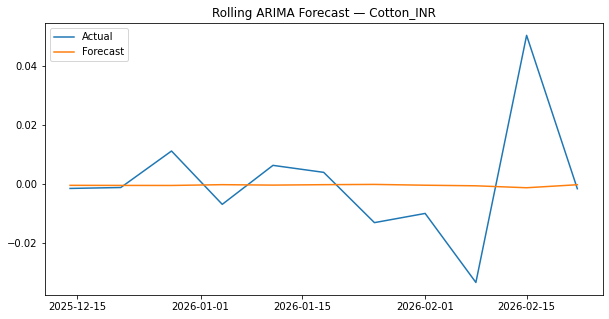


Rolling ARIMA → Potatoes_INR
RMSE: 0.09937348702560247
MAE: 0.07074470313317856


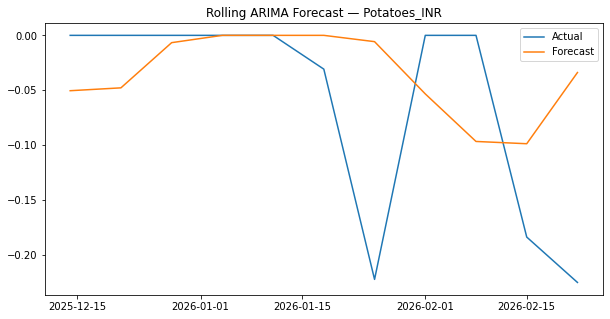


Rolling ARIMA → Corn_INR
RMSE: 0.01673885742353745
MAE: 0.013292811192115261


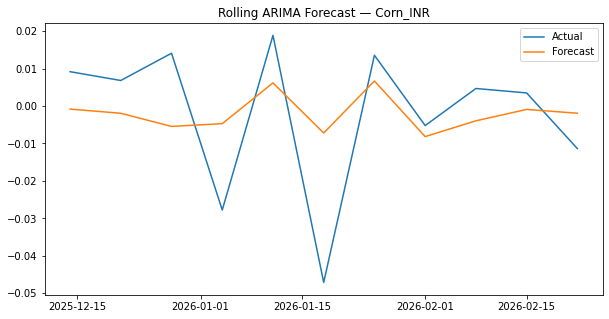


Rolling ARIMA → Potatoes
RMSE: 0.09937348222800631
MAE: 0.0707447027133888


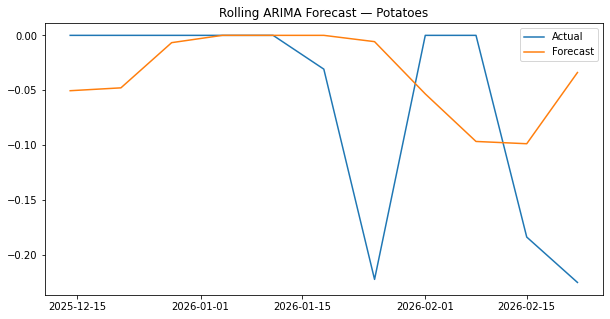


Rolling ARIMA → Rice
RMSE: 0.043673054845220306
MAE: 0.03447031102812791


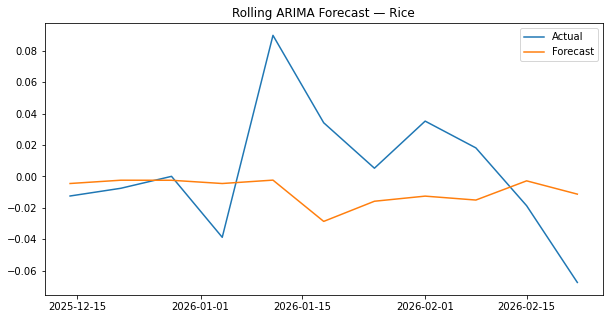


Rolling ARIMA → Soybeans
RMSE: 0.022306610270125246
MAE: 0.017744439377035893


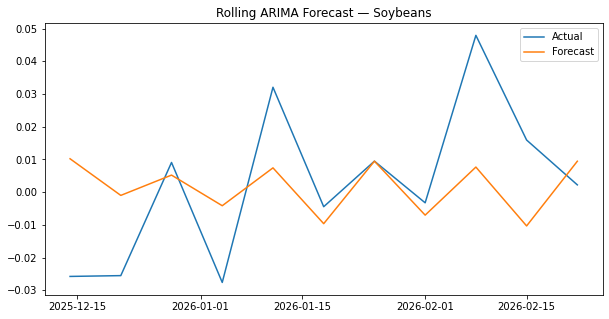


Rolling ARIMA → Coffee
RMSE: 0.0875423896607914
MAE: 0.06349087210927863


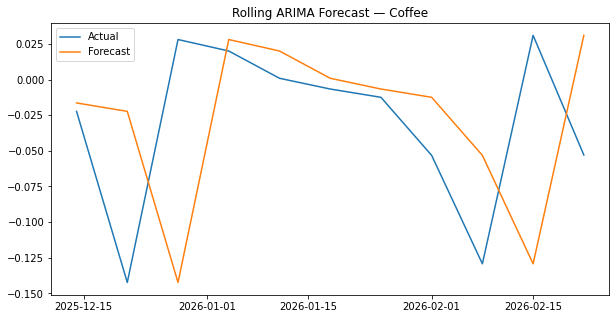


Rolling ARIMA → Cotton
RMSE: 0.019632592022003237
MAE: 0.012649241710262561


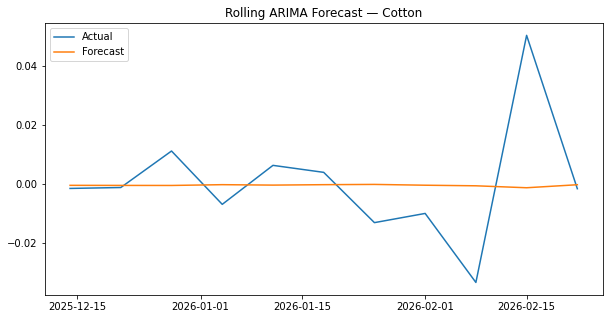


Rolling ARIMA → Sugar_INR
RMSE: 0.026415391441055612
MAE: 0.024852803752037942


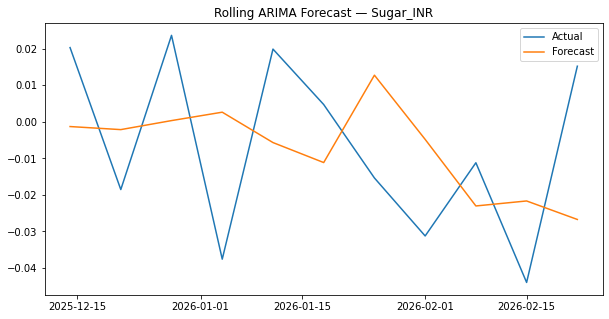

In [84]:
rolling_metrics = {}

for col in returns.columns:
    print(f"\nRolling ARIMA → {col}")
    
    series = returns[col].dropna()
    train_size = int(len(series) * 0.8)
    
    order = results[col]
    
    rmse, mae, preds = rolling_arima_forecast(series, order, train_size)
    
    rolling_metrics[col] = (rmse, mae)
    
    print("RMSE:", rmse)
    print("MAE:", mae)
    test = series[train_size:]

    plt.figure(figsize=(10,5))
    plt.plot(test.index, test.values, label="Actual")
    plt.plot(test.index, preds, label="Forecast")
    plt.legend()
    plt.title(f"Rolling ARIMA Forecast — {col}")
    plt.show()


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(returns["Tea"].dropna(), lags=20)
plot_pacf(returns["Tea"].dropna(), lags=20)


In [ ]:
plot_acf(returns["Wheat"].dropna()**2, lags=20)


In [ ]:
!pip install arch

In [ ]:
from arch import arch_model
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rolling_garch_forecast(series, train_size):
    history = list(series[:train_size])
    test = series[train_size:]
    
    predictions = []
    
    for t in range(len(test)):
        model = arch_model(
            np.array(history) * 100,
            mean="AR",
            lags=1,
            vol="Garch",
            p=1,
            q=1
        )
        
        fitted = model.fit(disp="off")
        forecast = fitted.forecast(horizon=1)
        
        pred = forecast.mean.iloc[-1, 0] / 100
        predictions.append(pred)
        
        history.append(test.iloc[t])
    
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)
    
    return rmse, mae, predictions


In [ ]:
series = returns["Wheat"].dropna()
train_size = int(len(series) * 0.8)

rmse, mae, preds = rolling_garch_forecast(series, train_size)

print("GARCH RMSE:", rmse)
print("GARCH MAE:", mae)


In [ ]:
rolling_metrics = {}

for col in returns.columns:
    print(f"\nRolling GARCH → {col}")
    
    series = returns[col].dropna()
    train_size = int(len(series) * 0.8)
    
    rmse, mae, preds = rolling_garch_forecast(series, train_size)
    
    rolling_metrics[col] = (rmse, mae)
    
    print("RMSE:", rmse)
    print("MAE:", mae)

    test = series[train_size:]

    plt.figure(figsize=(10,5))
    plt.plot(test.index, test.values, label="Actual")
    plt.plot(test.index, preds, label="Forecast")
    plt.legend()
    plt.title(f"Rolling GARCH Forecast — {col}")
    plt.show()


### Rolling

In [ ]:
print(prices.isna().sum())

In [ ]:
prices = prices.sort_index()
prices1 = prices.ffill()


In [ ]:
print(prices1.isna().sum())

In [ ]:
prices1["Tea"].plot()

In [ ]:
import numpy as np

k = 5  # 1 week ahead return (daily data)

rolling_returns = np.log(prices1.shift(-k) / prices1)
rolling_returns = rolling_returns.dropna()


In [ ]:
rolling_returns

In [ ]:
def rolling_garch_forecast(series, train_size):
    history = list(series[:train_size])
    test = series[train_size:]
    
    predictions = []
    sigmas = []
    
    for t in range(len(test)):
        model = arch_model(
            np.array(history) * 100,
            mean="AR",
            lags=1,
            vol="Garch",
            p=1,
            q=1
        )
        
        fitted = model.fit(disp="off")
        forecast = fitted.forecast(horizon=1)
        
        pred = forecast.mean.iloc[-1, 0] / 100
        var = forecast.variance.iloc[-1, 0]
        
        sigma = np.sqrt(var) / 100
        
        predictions.append(pred)
        sigmas.append(sigma)
        
        history.append(test.iloc[t])
    
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mae = mean_absolute_error(test, predictions)
    
    return rmse, mae, predictions, sigmas


In [ ]:
import numpy as np

def price_range(current_price, pred_return, sigma):
    expected = current_price * np.exp(pred_return)
    lower = current_price * np.exp(pred_return - sigma)
    upper = current_price * np.exp(pred_return + sigma)
    return expected, lower, upper


In [ ]:
def evaluate_dataset(dataset, name, prices):
    print(f"\n===== {name} =====")
    
    garch_metrics = {}
    
    for col in dataset.columns:
        print(f"\nCommodity: {col}")
        
        series = dataset[col].dropna()
        train_size = int(len(series) * 0.8)
        
        rmse_g, mae_g, garch_preds, sigmas = rolling_garch_forecast(series, train_size)
        
        garch_metrics[col] = (rmse_g, mae_g)
        
        print("ARIMA-GARCH RMSE:", rmse_g)
        
        test = series[train_size:]
        price_series = prices[col].loc[test.index]
        
        # Example price range for last prediction
        current_price = price_series.iloc[-1]
        pred_return = garch_preds[-1]
        sigma = sigmas[-1]
        
        expected, lower, upper = price_range(current_price, pred_return, sigma)
        
        print(f"Suggested price: {expected:.2f}")
        print(f"Range: [{lower:.2f}, {upper:.2f}]")
        
        plt.figure(figsize=(12,5))
        plt.plot(test.index, test.values, label="Actual", linewidth=2)
        plt.plot(test.index, garch_preds, label="GARCH Forecast")
        plt.title(f"{col} — ARIMA-GARCH ({name})")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    return garch_metrics


ARIMA-GARCH RMSE: 0.030256332313984932
Suggested price: 26408.04
Range: [25668.39, 27168.99]


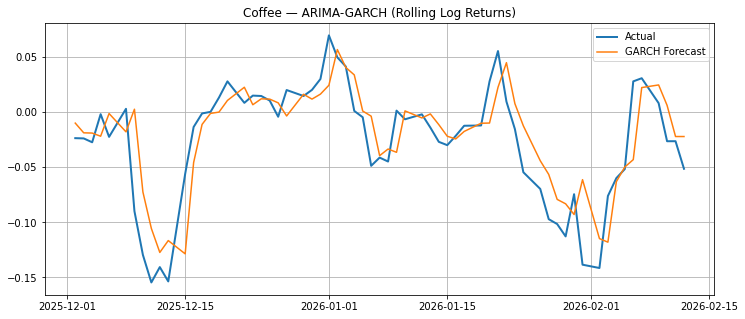


Commodity: Cotton
ARIMA-GARCH RMSE: 0.01031514377138664
Suggested price: 5824.63
Range: [5730.04, 5920.79]


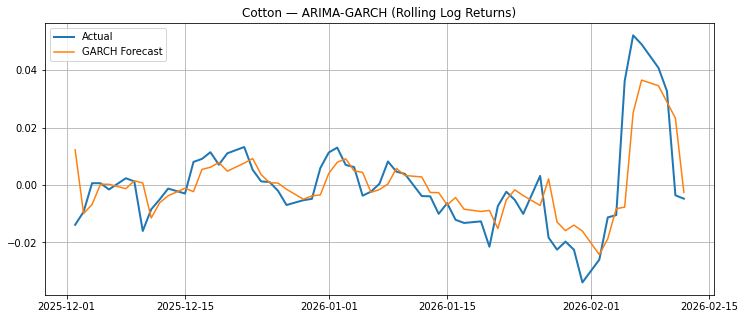


Commodity: Sugar_INR
ARIMA-GARCH RMSE: 0.016437062077369027
Suggested price: 1238.76
Range: [1217.40, 1260.49]


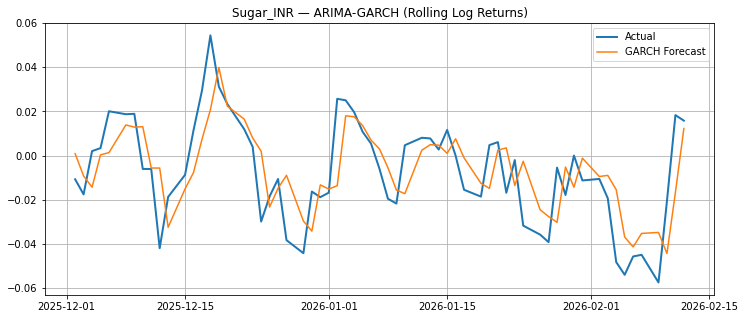

In [73]:
metrics = evaluate_dataset(rolling_returns, "Rolling Log Returns", prices)
